In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
df = pd.read_csv("data/heart.csv")
print("Dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded!
Rows: 1025
Columns: 14


In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 723


In [7]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 302


In [8]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_20352\4223434575.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


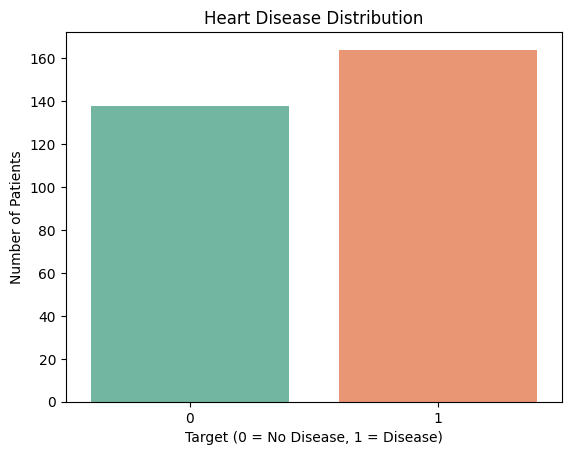

In [9]:
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Number of Patients')
plt.show()

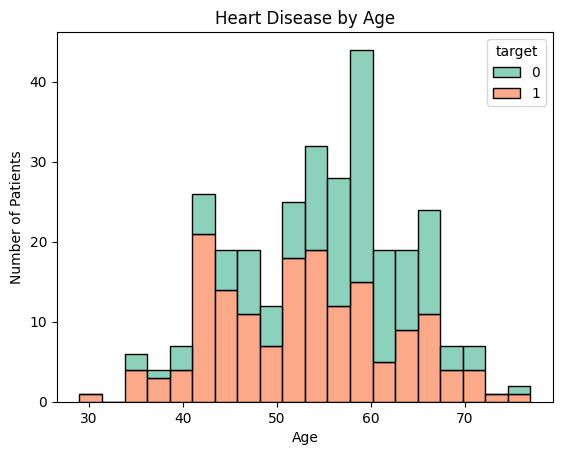

In [10]:
sns.histplot(data=df, x='age', hue='target', bins=20, palette='Set2', multiple='stack')
plt.title('Heart Disease by Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

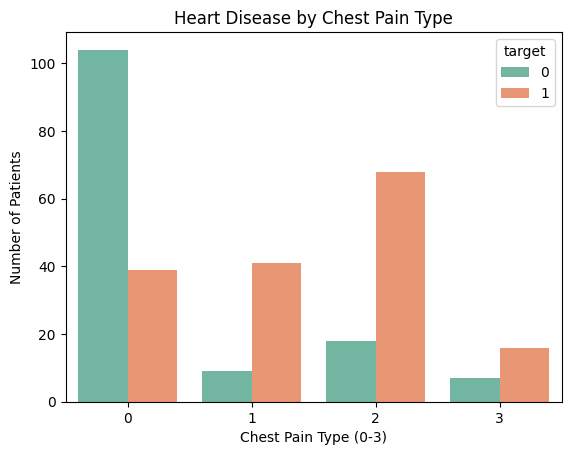

In [11]:
sns.countplot(x='cp', hue='target', data=df, palette='Set2')
plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Number of Patients')
plt.show()

In [12]:
X = df.drop(columns=['target'])
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (302, 13)
y shape: (302,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 241
Testing rows: 61


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, y_pred))

Accuracy: 77.05 %

              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



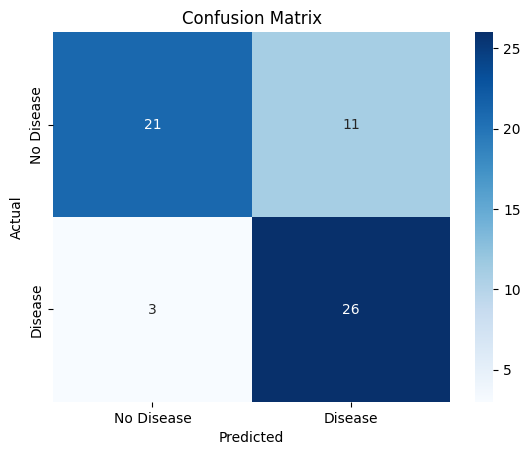

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 83.61 %

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



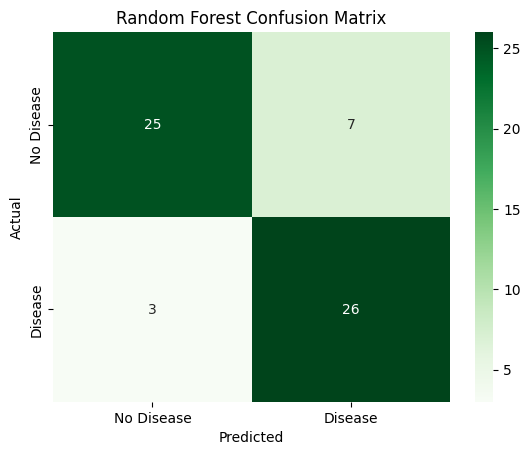

In [19]:
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_20352\3606947037.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')


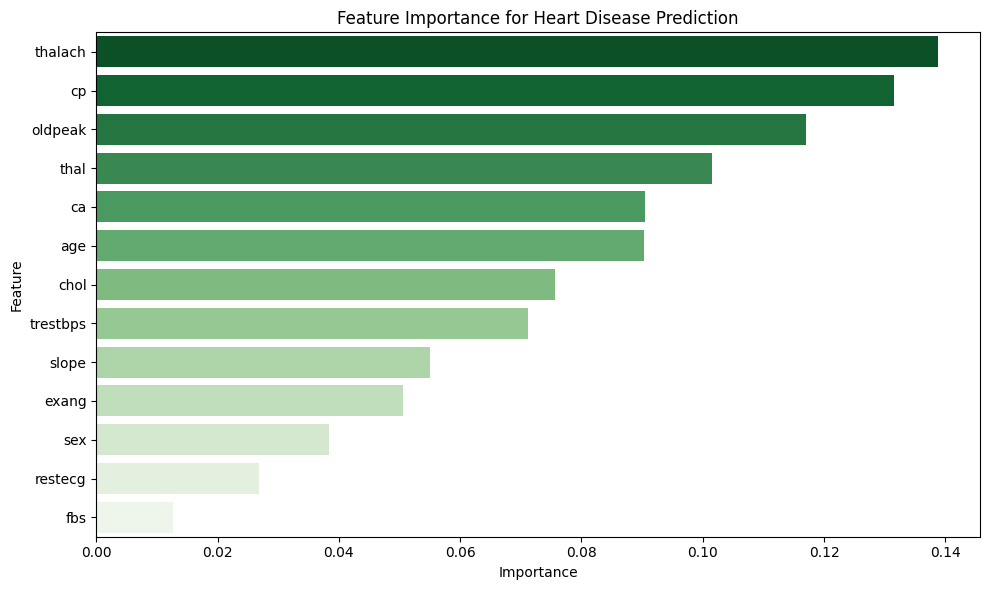

In [20]:
feature_names = X.columns
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')
plt.title('Feature Importance for Heart Disease Prediction')
plt.tight_layout()
plt.show()

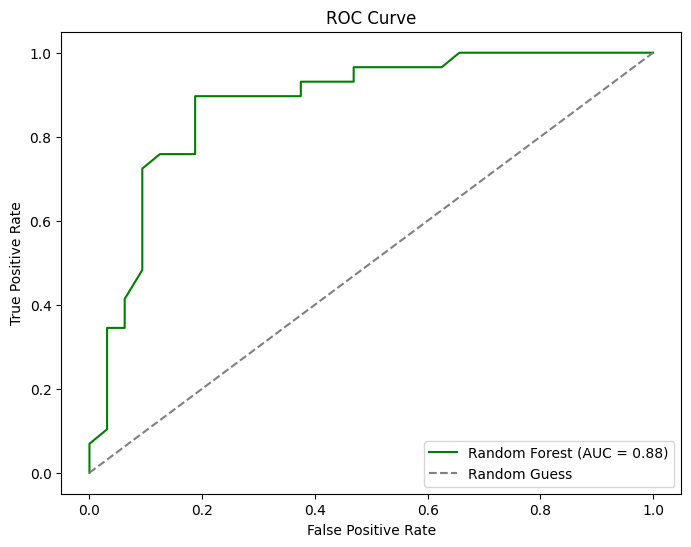

AUC Score: 0.8788


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("AUC Score:", round(auc_score, 4))

C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_20352\1358996736.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Blues_d', ax=ax1)
C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_20352\1358996736.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=disease_recall, palette='Greens_d', ax=ax2)


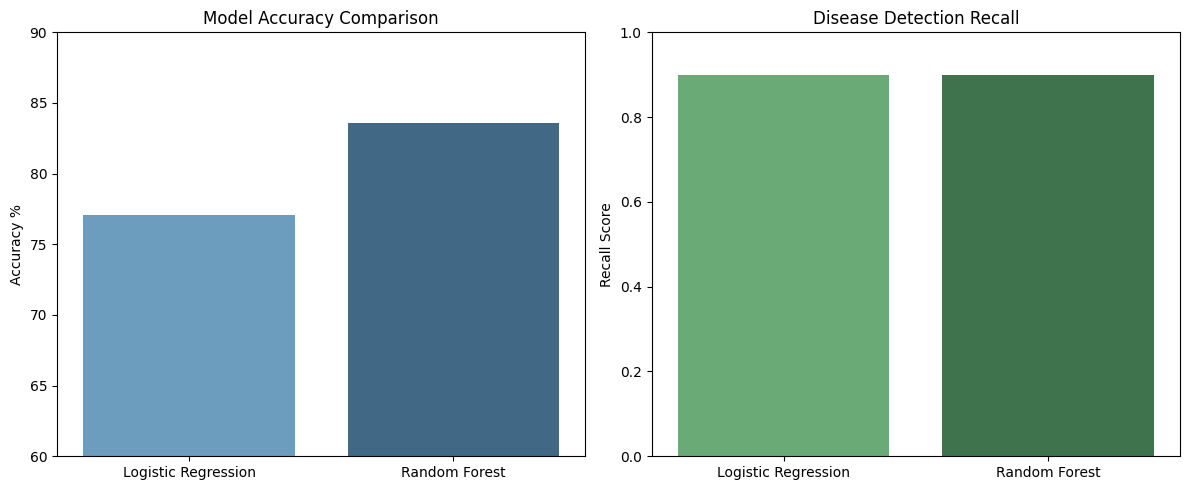

In [22]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [77.05, 83.61]
disease_recall = [0.90, 0.90]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=models, y=accuracies, palette='Blues_d', ax=ax1)
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy %')
ax1.set_ylim(60, 90)

sns.barplot(x=models, y=disease_recall, palette='Greens_d', ax=ax2)
ax2.set_title('Disease Detection Recall')
ax2.set_ylabel('Recall Score')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()